# Milestone: First Reliable EEG — Alpha Rhythm Validated (Grommet Cap)

## Result
Achieved repeatable, good-quality EEG recording of my own alpha rhythm using
the self-built PiEEG-16 setup. Across three consecutive eyes-closed/eyes-open
runs (no re-gelling between them):
- **ch15 (occipital): alpha ratio 4.88 / 5.65 / 6.54** — passed every run
- **ch16 (occipital): alpha ratio 2.79 / 4.81 / 5.41** — passed every run
- Noise floor (>60 Hz power) held **stable at 44–52%** across all runs
- (ch14 remained weak (~1.0) — single-electrode contact issue, not a setup
  failure)

Bar set beforehand: floor <50%, alpha >1.7, steady across ≥3 runs. Two of three
occipital channels cleared it cleanly and repeatably — the EEG is validated.

## What finally worked
- **Silicone/rubber grommets** seated in enlarged beanie holes. This solved the
  three problems the plain beanie couldn't:
  1. **Scalp access** — enlarged holes let me part hair and gel the scalp
     directly (closed knit fabric had blocked this).
  2. **Stable electrode holding** — grommets grip the electrode firmly and lock
     to the cap, vs. loose knit that let electrodes slide and drift.
  3. **Consistent contact over time** — stable seating stopped the noise floor
     from degrading mid-session, which had been a persistent failure.

## The journey (why this took many sessions)
- Silicone swim cap: too slippery/non-snug — abandoned, repurposed as a
  reference-electrode pressure band.
- Cotton beanie: better grip/breathability, but **closed fabric blocked scalp
  access** — the core, ultimately fatal limitation.
- Iterated through velcro (electrode stability), elastic band orientation
  (fixed noise-floor drift), pre-gel/hair-part method, electrode cleaning.
- Key diagnostic: shorting all inputs proved the 30–60 Hz noise came from
  electrode/reference contact, not the board.
- Learned the hard way: results swung session-to-session because multiple
  variables changed at once + no scalp access. Fixed by disciplined
  one-variable-at-a-time testing and a defined pass condition.
- Concluded the beanie was at its ceiling → added grommets (cheap, ~$6–15)
  rather than buying an expensive clinical cap. The targeted fix worked.

## Lessons
- Contact quality — especially the shared reference/bias — gates every channel.
- Noise-floor % (>60 Hz) and eyes-closed alpha ratio are the metrics that
  matter; raw traces are not eyeball-readable at this noise level.
- Repeatability (same result across ≥3 runs) is the real bar, not one good run.
- A cheap targeted fix (grommets) beat both endless beanie tweaking and an
  expensive cap — let the cheapest viable fix prove itself first.

## Next
- Optional: re-seat ch14 for a clean 3/3 sweep.
- Move toward motor imagery (C3/C4, mu rhythm) — harder contact + subtler
  signal than occipital alpha; will need this same contact discipline.
- Connect the validated src/ CSP+LDA pipeline to real recorded data.

Saved figure to /home/beecki303/projects/bci/docs/first_real_eeg_alpha.png


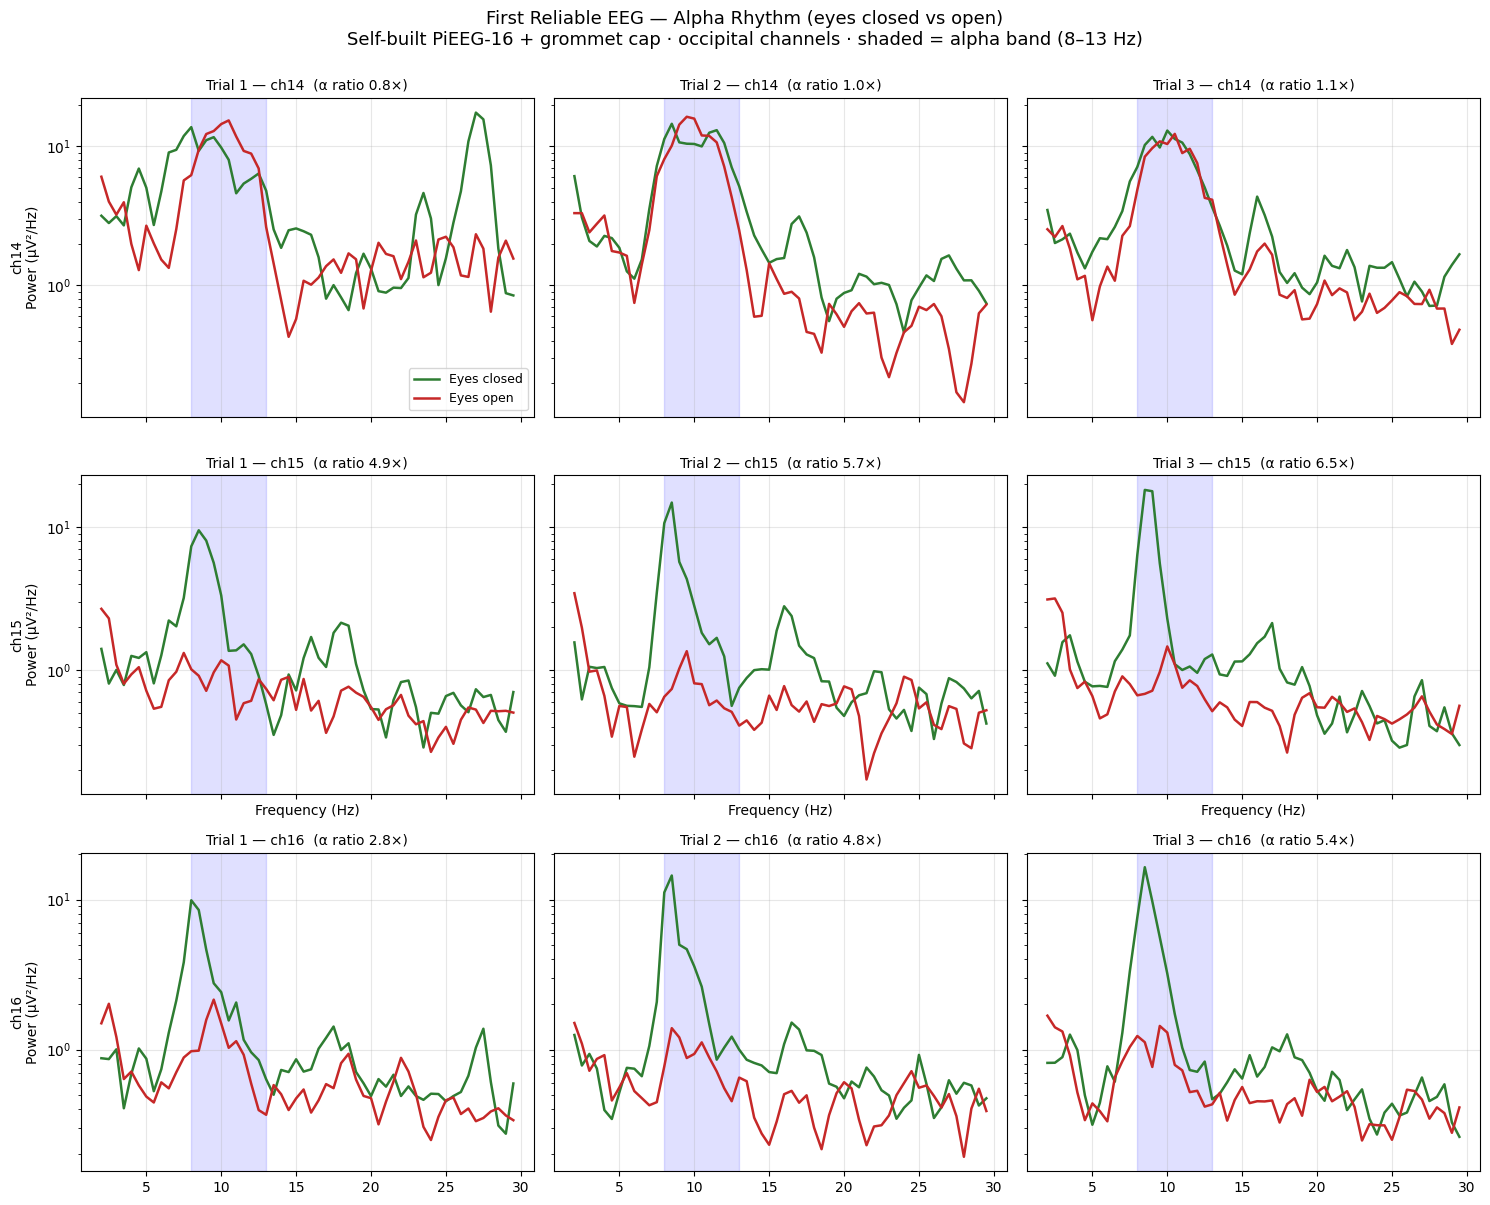

In [ ]:
import pandas as pd, numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from pathlib import Path

trap = getattr(np, 'trapezoid', None) or np.trapz

# Your three grommet-setup trials (adjust path to where your CSVs live)
data_dir = Path.home() / "projects" / "bci" / "data" / "raw"   
files = sorted([
    "pieeg_20260803_172526_annotated.csv",
    "pieeg_20260803_172833_annotated.csv",
    "pieeg_20260803_173034_annotated.csv",
])

def clean(v, fs):
    v = v.astype(float); v -= v.mean()
    bn, an = signal.iirnotch(60.0, Q=30, fs=fs); v = signal.filtfilt(bn, an, v)
    sos = signal.butter(4, [1, 45], btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, v)

# --- Build a figure: eyes-closed vs eyes-open spectra for the two good channels ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey='row')
good_channels = ['ch14','ch15', 'ch16']   # your two validated occipital channels and one that didnt make sufficient conatact

for col, fn in enumerate(files):
    df = pd.read_csv(data_dir / fn) if (data_dir / fn).exists() else pd.read_csv(fn)
    fs = len(df) / (df['time_s'].iloc[-1] - df['time_s'].iloc[0])
    ann = list(zip(df[df['annotation'].notna()]['time_s'].values,
                   df[df['annotation'].notna()]['annotation'].values))
    t = df['time_s'].values
    cstart = next((x for x, l in ann if 'clos' in str(l).lower()), 0)
    ostart = next((x for x, l in ann if 'open' in str(l).lower()), t[-1]/2)
    closed = (t >= cstart+1) & (t <= ostart-0.5)
    openm  = (t >= ostart+1) & (t <= t[-1]-0.5)

    for row, ch in enumerate(good_channels):
        ax = axes[row, col]
        for seg, label, color in [(closed, 'Eyes closed', '#2E7D32'),
                                   (openm, 'Eyes open', '#C62828')]:
            vf = clean(df[ch].values[seg], fs)
            f, pxx = signal.welch(vf, fs=fs, nperseg=int(fs*2))
            mask = (f >= 2) & (f <= 30)
            ax.semilogy(f[mask], pxx[mask], color=color, linewidth=1.8, label=label)
        # shade the alpha band
        ax.axvspan(8, 13, alpha=0.12, color='blue')
        # compute the alpha ratio for the title
        def apw(seg):
            vf = clean(df[ch].values[seg], fs)
            f, pxx = signal.welch(vf, fs=fs, nperseg=int(fs*2))
            m = (f >= 8) & (f <= 13); return trap(pxx[m], f[m])
        ratio = apw(closed) / apw(openm)
        ax.set_title(f"Trial {col+1} — {ch}  (α ratio {ratio:.1f}×)", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{ch}\nPower (µV²/Hz)")
        if row == 1:
            ax.set_xlabel("Frequency (Hz)")
        if row == 0 and col == 0:
            ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

fig.suptitle("First Reliable EEG — Alpha Rhythm (eyes closed vs open)\n"
             "Self-built PiEEG-16 + grommet cap · occipital channels · shaded = alpha band (8–13 Hz)",
             fontsize=13, y=1.00)
plt.tight_layout()

# Save it as a portfolio artifact
out = Path.home() / "projects" / "bci" / "docs" / "first_real_eeg_alpha.png"
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f"Saved figure to {out}")
plt.show()

In [2]:
import time, random, csv
from datetime import datetime

# --- Experiment parameters ---
N_TRIALS = 40            # total trials (~20 per class)
READY_SEC = 2.0          # calm/fixation before cue
IMAGERY_SEC = 4.0        # imagine the movement
REST_SEC = 4.0           # rest between trials
CLASSES = ['LEFT', 'RIGHT']

# Log file for cues (this becomes your labels)
logfile = f"cues_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

# Build a balanced, shuffled sequence (equal L/R, randomized order)
seq = CLASSES * (N_TRIALS // 2)
random.shuffle(seq)

print(f"Starting in 5 seconds — start your EEG recording NOW.")
print(f"Cues will be logged to {logfile}")
time.sleep(5)

start = time.time()
with open(logfile, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['trial', 'cue_time_s', 'label'])
    for i, label in enumerate(seq, 1):
        # get ready
        print(f"\nTrial {i}/{len(seq)} — get ready...")
        time.sleep(READY_SEC)
        # cue
        cue_time = time.time() - start
        print(f">>> {label} <<<   (imagine for {IMAGERY_SEC:.0f}s)")
        w.writerow([i, round(cue_time, 3), label])
        f.flush()
        time.sleep(IMAGERY_SEC)
        # rest
        print("rest...")
        time.sleep(REST_SEC)

print(f"\nDone. {len(seq)} cues logged to {logfile}.")

Starting in 5 seconds — start your EEG recording NOW.
Cues will be logged to cues_20260806_180426.csv

Trial 1/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 2/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 3/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 4/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 5/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 6/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 7/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 8/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 9/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 10/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 11/40 — get ready...
>>> LEFT <<<   (imagine for 4s)
rest...

Trial 12/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 13/40 — get ready...
>>> RIGHT <<<   (imagine for 4s)
rest...

Trial 14/40 — ge

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.home() / "projects" / "bci"))

import pandas as pd, numpy as np
from scipy import signal
from src import pipeline   # your validated CSP+LDA + evaluate

# --- Load the PiEEG recording ---
csv = data_dir = Path.home() / "projects" / "bci" / "data" / "raw" / "pieeg_20260805_234523_annotated.csv"   
df = pd.read_csv(csv, low_memory=False)
fs = len(df) / (df['time_s'].iloc[-1] - df['time_s'].iloc[0])
t = df['time_s'].values
print(f"Loaded {len(df)} samples at ~{fs:.0f} Hz")

# --- Cue log (time, label) ---
cues = [(2.001,'LEFT'),(12.001,'RIGHT'),(22.002,'LEFT'),(32.003,'LEFT'),(42.003,'LEFT'),
(52.004,'LEFT'),(62.005,'RIGHT'),(72.005,'LEFT'),(82.006,'LEFT'),(92.007,'LEFT'),
(102.007,'LEFT'),(112.008,'RIGHT'),(122.009,'LEFT'),(132.009,'LEFT'),(142.01,'LEFT'),
(152.011,'LEFT'),(162.011,'RIGHT'),(172.012,'LEFT'),(182.013,'LEFT'),(192.013,'LEFT'),
(202.014,'RIGHT'),(212.015,'RIGHT'),(222.015,'LEFT'),(232.016,'LEFT'),(242.017,'RIGHT'),
(252.017,'RIGHT'),(262.018,'RIGHT'),(272.019,'RIGHT'),(282.02,'RIGHT'),(292.02,'RIGHT'),
(302.021,'LEFT'),(312.022,'RIGHT'),(322.022,'RIGHT'),(332.023,'LEFT'),(342.024,'RIGHT'),
(352.024,'RIGHT'),(362.025,'RIGHT'),(372.026,'RIGHT'),(382.026,'RIGHT'),(392.027,'RIGHT')]

# --- Filter the motor channels (notch + 8-30 bandpass), same as your pipeline's band ---
motor_ch = ['ch6','ch7','ch8']
def prep(v):
    v = v.astype(float); v -= v.mean()
    bn, an = signal.iirnotch(60.0, Q=30, fs=fs); v = signal.filtfilt(bn, an, v)
    sos = signal.butter(4, [8,30], btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, v)

filtered = {c: prep(df[c].values) for c in motor_ch}

# --- Epoch: 0.5-3.5s after each cue -> X (trials, channels, samples), y (labels) ---
TMIN, TMAX = 0.5, 3.5
X, y = [], []
for ct, lab in cues:
    mask = (t >= ct+TMIN) & (t < ct+TMAX)
    idx = np.where(mask)[0]
    if len(idx) < 10: 
        continue
    # fixed length across trials
    n = int((TMAX-TMIN)*fs)
    idx = idx[:n]
    if len(idx) < n:
        continue
    trial = np.stack([filtered[c][idx] for c in motor_ch])  # (channels, samples)
    X.append(trial)
    y.append(0 if lab=='LEFT' else 1)

X = np.array(X)              # (trials, channels, samples)
y = np.array(y)
print(f"Epoched: X = {X.shape}, y = {y.shape}, balance = {np.bincount(y)}")

# --- Run YOUR validated pipeline ---
# n_components must be <= channels; you have 3 channels, so use 2
result = pipeline.evaluate(X, y, n_components=2)
print(f"\nCSP+LDA cross-validated accuracy: {result['mean']:.3f} (±{result['std']:.3f})")
print(f"Chance level: {result['chance']:.3f}")
print(f"Per-fold: {result['scores'].round(3)}")

Loaded 99010 samples at ~250 Hz
Epoched: X = (40, 3, 750), y = (40,), balance = [20 20]
Computing rank from data with rank=None
    Using tolerance 0.81 (2.2e-16 eps * 3 dim * 1.2e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.84 (2.2e-16 eps * 3 dim * 1.3e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.83 (2.2e-16 eps * 3 dim * 1.2e+15  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing 

In [5]:
import sys
from pathlib import Path
sys.path.append(str(Path.home() / "projects" / "bci"))

import pandas as pd, numpy as np
from scipy import signal
from src import pipeline   # your validated CSP+LDA + evaluate

# --- Load the PiEEG recording ---
csv = data_dir = Path.home() / "projects" / "bci" / "data" / "raw" / "pieeg_20260806_175413_annotated.csv"   
df = pd.read_csv(csv, low_memory=False)
fs = len(df) / (df['time_s'].iloc[-1] - df['time_s'].iloc[0])
t = df['time_s'].values
print(f"Loaded {len(df)} samples at ~{fs:.0f} Hz")

# --- Cue log (time, label) ---
cues = [(2.001,'LEFT'),(12.001,'RIGHT'),(22.002,'LEFT'),(32.003,'LEFT'),(42.003,'LEFT'),
(52.004,'LEFT'),(62.005,'RIGHT'),(72.005,'LEFT'),(82.006,'LEFT'),(92.007,'LEFT'),
(102.007,'LEFT'),(112.008,'RIGHT'),(122.009,'LEFT'),(132.009,'LEFT'),(142.01,'LEFT'),
(152.011,'LEFT'),(162.011,'RIGHT'),(172.012,'LEFT'),(182.013,'LEFT'),(192.013,'LEFT'),
(202.014,'RIGHT'),(212.015,'RIGHT'),(222.015,'LEFT'),(232.016,'LEFT'),(242.017,'RIGHT'),
(252.017,'RIGHT'),(262.018,'RIGHT'),(272.019,'RIGHT'),(282.02,'RIGHT'),(292.02,'RIGHT'),
(302.021,'LEFT'),(312.022,'RIGHT'),(322.022,'RIGHT'),(332.023,'LEFT'),(342.024,'RIGHT'),
(352.024,'RIGHT'),(362.025,'RIGHT'),(372.026,'RIGHT'),(382.026,'RIGHT'),(392.027,'RIGHT')]

# --- Filter the motor channels (notch + 8-30 bandpass), same as your pipeline's band ---
motor_ch = ['ch6','ch7','ch8']
def prep(v):
    v = v.astype(float); v -= v.mean()
    bn, an = signal.iirnotch(60.0, Q=30, fs=fs); v = signal.filtfilt(bn, an, v)
    sos = signal.butter(4, [8,30], btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, v)

filtered = {c: prep(df[c].values) for c in motor_ch}

# --- Epoch: 0.5-3.5s after each cue -> X (trials, channels, samples), y (labels) ---
TMIN, TMAX = 0.5, 3.5
X, y = [], []
for ct, lab in cues:
    mask = (t >= ct+TMIN) & (t < ct+TMAX)
    idx = np.where(mask)[0]
    if len(idx) < 10: 
        continue
    # fixed length across trials
    n = int((TMAX-TMIN)*fs)
    idx = idx[:n]
    if len(idx) < n:
        continue
    trial = np.stack([filtered[c][idx] for c in motor_ch])  # (channels, samples)
    X.append(trial)
    y.append(0 if lab=='LEFT' else 1)

X = np.array(X)              # (trials, channels, samples)
y = np.array(y)
print(f"Epoched: X = {X.shape}, y = {y.shape}, balance = {np.bincount(y)}")

# --- Run YOUR validated pipeline ---
# n_components must be <= channels; you have 3 channels, so use 2
result = pipeline.evaluate(X, y, n_components=2)
print(f"\nCSP+LDA cross-validated accuracy: {result['mean']:.3f} (±{result['std']:.3f})")
print(f"Chance level: {result['chance']:.3f}")
print(f"Per-fold: {result['scores'].round(3)}")

Loaded 97047 samples at ~250 Hz
Epoched: X = (39, 3, 750), y = (39,), balance = [20 19]
Computing rank from data with rank=None
    Using tolerance 4.6e+02 (2.2e-16 eps * 3 dim * 6.9e+17  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.43 (2.2e-16 eps * 3 dim * 6.5e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 4.6e+02 (2.2e-16 eps * 3 dim * 6.9e+17  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Red

In [6]:
import sys
from pathlib import Path
sys.path.append(str(Path.home() / "projects" / "bci"))

import pandas as pd, numpy as np
from scipy import signal
from src import pipeline   # your validated CSP+LDA + evaluate

# --- Load the PiEEG recording ---
csv = data_dir = Path.home() / "projects" / "bci" / "data" / "raw" / "pieeg_20260806_180425_annotated.csv"   
df = pd.read_csv(csv, low_memory=False)
fs = len(df) / (df['time_s'].iloc[-1] - df['time_s'].iloc[0])
t = df['time_s'].values
print(f"Loaded {len(df)} samples at ~{fs:.0f} Hz")

# --- Cue log (time, label) ---
cues = [(2.001,'LEFT'),(12.001,'RIGHT'),(22.002,'LEFT'),(32.003,'LEFT'),(42.003,'LEFT'),
(52.004,'LEFT'),(62.005,'RIGHT'),(72.005,'LEFT'),(82.006,'LEFT'),(92.007,'LEFT'),
(102.007,'LEFT'),(112.008,'RIGHT'),(122.009,'LEFT'),(132.009,'LEFT'),(142.01,'LEFT'),
(152.011,'LEFT'),(162.011,'RIGHT'),(172.012,'LEFT'),(182.013,'LEFT'),(192.013,'LEFT'),
(202.014,'RIGHT'),(212.015,'RIGHT'),(222.015,'LEFT'),(232.016,'LEFT'),(242.017,'RIGHT'),
(252.017,'RIGHT'),(262.018,'RIGHT'),(272.019,'RIGHT'),(282.02,'RIGHT'),(292.02,'RIGHT'),
(302.021,'LEFT'),(312.022,'RIGHT'),(322.022,'RIGHT'),(332.023,'LEFT'),(342.024,'RIGHT'),
(352.024,'RIGHT'),(362.025,'RIGHT'),(372.026,'RIGHT'),(382.026,'RIGHT'),(392.027,'RIGHT')]

# --- Filter the motor channels (notch + 8-30 bandpass), same as your pipeline's band ---
motor_ch = ['ch6','ch7','ch8']
def prep(v):
    v = v.astype(float); v -= v.mean()
    bn, an = signal.iirnotch(60.0, Q=30, fs=fs); v = signal.filtfilt(bn, an, v)
    sos = signal.butter(4, [8,30], btype='bandpass', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, v)

filtered = {c: prep(df[c].values) for c in motor_ch}

# --- Epoch: 0.5-3.5s after each cue -> X (trials, channels, samples), y (labels) ---
TMIN, TMAX = 0.5, 3.5
X, y = [], []
for ct, lab in cues:
    mask = (t >= ct+TMIN) & (t < ct+TMAX)
    idx = np.where(mask)[0]
    if len(idx) < 10: 
        continue
    # fixed length across trials
    n = int((TMAX-TMIN)*fs)
    idx = idx[:n]
    if len(idx) < n:
        continue
    trial = np.stack([filtered[c][idx] for c in motor_ch])  # (channels, samples)
    X.append(trial)
    y.append(0 if lab=='LEFT' else 1)

X = np.array(X)              # (trials, channels, samples)
y = np.array(y)
print(f"Epoched: X = {X.shape}, y = {y.shape}, balance = {np.bincount(y)}")

# --- Run YOUR validated pipeline ---
# n_components must be <= channels; you have 3 channels, so use 2
result = pipeline.evaluate(X, y, n_components=2)
print(f"\nCSP+LDA cross-validated accuracy: {result['mean']:.3f} (±{result['std']:.3f})")
print(f"Chance level: {result['chance']:.3f}")
print(f"Per-fold: {result['scores'].round(3)}")

Loaded 96703 samples at ~250 Hz
Epoched: X = (39, 3, 750), y = (39,), balance = [20 19]
Computing rank from data with rank=None
    Using tolerance 0.4 (2.2e-16 eps * 3 dim * 6e+14  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.7e+02 (2.2e-16 eps * 3 dim * 8.6e+17  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.7e+02 (2.2e-16 eps * 3 dim * 8.6e+17  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reduci